In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 1:** Searching for contamination sources

I am tasked with detecting likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

- **Optimisation Goal**: Maximise
- **Input:** 2D array. The initial dataset contained 11 observations. 
    - Now the data set includes my 11 weeks of manual and model-driven queries, the dataset now contains 21 data points.

- **All time best:** 2.80e-06 at [0.472, 0.352] (Week 5)

In [2]:
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy')

# New data for Week 11 (Function 1)
X_w11_new_point = np.array([0.521101, 0.340595], dtype=np.float64)
Y_w11_new_point = np.array([2.3867665752574216e-12], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w11_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w11_new_point)
Y_updated = Y_all[unique_indices]

# Save the updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 1: ", X_unique)
print("Updated Outputs (Y) - Function 1: ", Y_updated)

Updated Inputs (X) - Function 1:  [[0.08250725 0.40348751]
 [0.31269116 0.07872278]
 [0.31940389 0.76295937]
 [0.378447   0.273576  ]
 [0.41043714 0.1475543 ]
 [0.472      0.332     ]
 [0.472361   0.351758  ]
 [0.521101   0.340595  ]
 [0.57432921 0.8798981 ]
 [0.575251   0.879599  ]
 [0.65011406 0.68152635]
 [0.68341817 0.86105746]
 [0.73102363 0.73299988]
 [0.732441   0.040134  ]
 [0.76642    0.752405  ]
 [0.799197   0.803213  ]
 [0.819277   0.694779  ]
 [0.84035342 0.26473161]
 [0.88388983 0.58225397]
 [0.919191   0.838383  ]
 [0.996651   0.001439  ]]
Updated Outputs (Y) - Function 1:  [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079 -4.58534168e-018
 -2.15924904e-054  1.82102900e-008  2.80463460e-006  2.38676658e-012
  1.03307824e-046  1.46776061e-046 -3.60606264e-003  2.53500115e-040
  7.71087511e-016 -5.11184814e-169  4.64114908e-025  4.75768881e-042
 -1.84087865e-029  3.34177101e-124  6.22985647e-048 -3.04056455e-090
  0.00000000e+000]


## **Output Analysis**

- Last week I got the output of 4.64e-25 (zero, distant region), this week (w11) I got the output of 2.39e-12 at [0.521, 0.341], which is a new meaningful positive reading.

- W11 queried [0.521, 0.341], which is displaced from the confirmed x1=0.472 corridor but still returned a positive (if tiny) reading. 
    - This is only the third non-zero positive in eleven weeks. Importantly, x2=0.341 is between the w5 best (x2=0.352) and the w9 south-step (x2=0.332), and x1=0.521 is further right than the known corridor.

- **Real-World Implication:** In radiation field mapping, getting a positive reading at [0.521, 0.341] does not necessarily indicate a second source, it may indicate the contamination field has a wider spread than assumed. 
    - However, it is weaker than both w5 and w9 readings, suggesting the signal strength still peaks near x1≈0.472.

- **Model Clues:** Three positive readings now exist: [0.472, 0.352]=2.80e-6, [0.472, 0.332]=1.82e-8, [0.521, 0.341]=2.39e-12. The strongest is at x1=0.472, x2=0.352. 
    - w12 must exploit this by querying directly at the w5 best [0.472, 0.352], still the all-time best, to confirm its reproducibility.

## **Bayesian Optimisation**

- I am using the Matern (nu=2.5) + WhiteKernel + Yeo-Johnson. 
    - No changes as I now have three non-zero anchor points giving the GP its first meaningful gradient structure.

- A neural network surrogate was considered but rejected. 
    - With only three non-zero readings out of 20+ total, a NN would overfit catastrophically to the noise. 
    
- The GP's posterior uncertainty is critical here as it tells us *where we haven't looked* rather than just *what we've seen*. 
    - A NN cannot provide this.

In [4]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20)

model.fit(X_unique, Y_transformed)

Original Y: [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079 -4.58534168e-018
 -2.15924904e-054  1.82102900e-008  2.80463460e-006  2.38676658e-012
  1.03307824e-046  1.46776061e-046 -3.60606264e-003  2.53500115e-040
  7.71087511e-016 -5.11184814e-169  4.64114908e-025  4.75768881e-042
 -1.84087865e-029  3.34177101e-124  6.22985647e-048 -3.04056455e-090
  0.00000000e+000]
Transformed Y: [ 0.22036755  0.22036755  0.22036755  0.22036755  0.22036755  0.22078005
  0.28432633  0.22036761  0.22036755  0.22036755 -4.4717224   0.22036755
  0.22036755  0.22036755  0.22036755  0.22036755  0.22036755  0.22036755
  0.22036755  0.22036755  0.22036755]


/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**
- **Key change:** The GP now has enough structure to begin forming a useful gradient. 
    - I am re-queries the W5 best at [0.472, 0.352] to confirm reproducibility, which also gives the model its first repeated-location data point.

In [ ]:
def expected_improvement(X, model, y_max, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)

    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Create a search grid
x_grid = np.array(np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))).T.reshape(-1, 2)

x_best = X_unique[np.argmax(Y_transformed)]

# Find the best transformed Y value
best_y_transformed = np.max(Y_transformed)

# Calculate EI values
ei_values = expected_improvement(x_grid, model, best_y_transformed)
next_query = x_grid[np.argmax(ei_values)]

print(f"Week 12 Query Recommendation: {next_query[0]:.6f}-{next_query[1]:.6f}")

Week 12 Query Recommendation: 0.321608-0.180905


## **Visualisation**

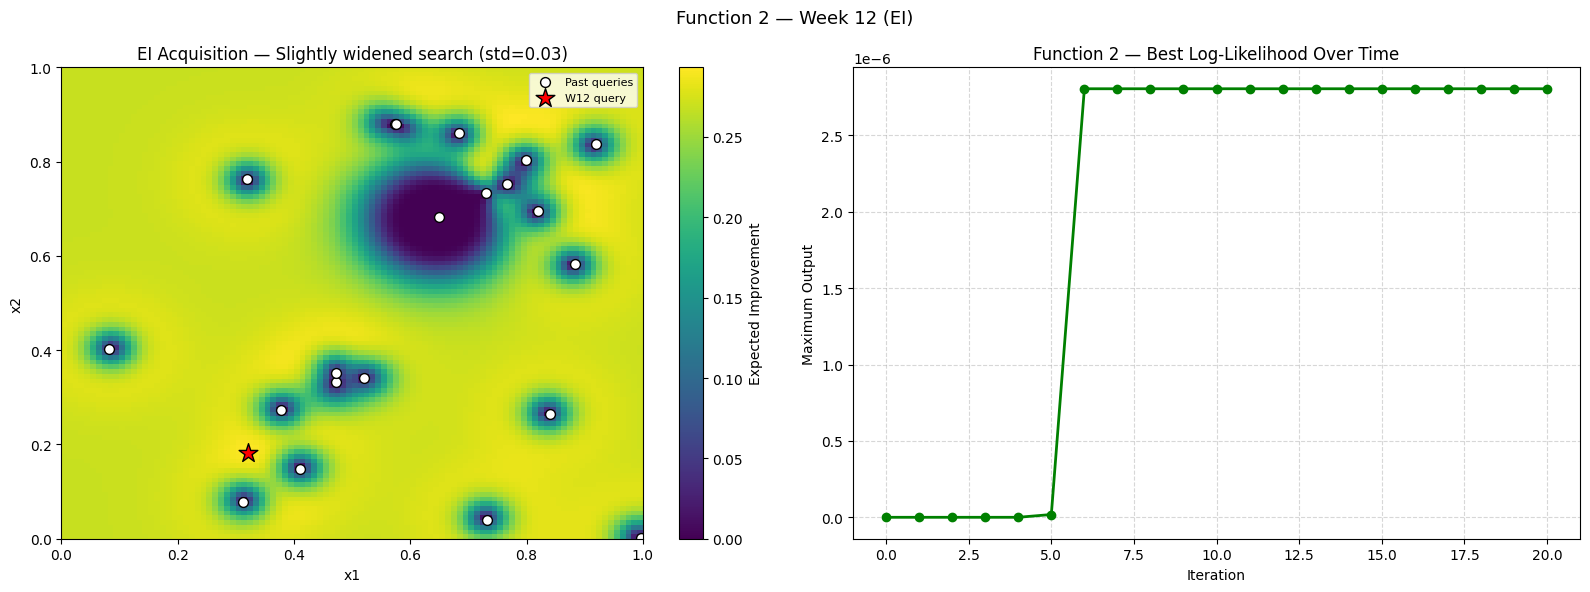

In [10]:
res = 100
X1, X2 = np.meshgrid(np.linspace(0, 1, res), np.linspace(0, 1, res))
X_plot = np.vstack([X1.ravel(), X2.ravel()]).T
ei_plot = expected_improvement(X_plot, model, best_y_transformed, xi=0.01).reshape(res, res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sc = ax1.imshow(ei_plot, extent=[0,1,0,1], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(sc, ax=ax1, label='Expected Improvement')
ax1.scatter(X_unique[:,0], X_unique[:,1], c='white', edgecolors='black', s=50, label='Past queries')
ax1.scatter(next_query[0], next_query[1], c='red', marker='*', s=200, edgecolors='black', zorder=7, label='W12 query')
ax1.set_title('EI Acquisition — Slightly widened search (std=0.03)')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.legend(fontsize=8)

running_max = np.maximum.accumulate(Y_updated)
ax2.plot(running_max, marker='o', color='green', linewidth=2)
ax2.set_title('Function 2 — Best Log-Likelihood Over Time')
ax2.set_xlabel('Iteration'); ax2.set_ylabel('Maximum Output')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 2 — Week 12 (EI)', fontsize=13)
plt.tight_layout()
plt.show()